Import and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the parquet file built by fetch_data.py
df = pd.read_parquet('../data/tracks.parquet')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()

# Quick peek at the data
df.head(10)

Dataset shape: (999, 11)
Columns: ['id', 'name', 'artist', 'valence', 'energy', 'danceability', 'tempo', 'acousticness', 'instrumentalness', 'preview_url', 'album_image']



,id,name,artist,valence,energy,danceability,tempo,acousticness,instrumentalness,preview_url,album_image
0,0NLkVxf0PyxsXBG3EuZcJf,Gul,Anuv Jain,0.342,0.294,0.600,86.970,0.8710,0.000087,None,None
1,6VBhH7CyP56BXjp8VsDFPZ,"Kesariya (From ""Brahmastra"")",Pritam;Arijit Singh;Amitabh Bhattacharya,0.436,0.574,0.577,94.009,0.5720,0.000000,None,None
2,7MBqVOzb8C3f0FXr2LBLiq,"Doobey (From ""Gehraiyaan"")",OAFF;Savera;Lothika;Kausar Munir,0.359,0.669,0.751,119.014,0.3420,0.000013,None,None
3,1rDjwexewf4hrdZT7SRNsH,Nasha (Equals Sessions),Faridkot;Amar Jalal,0.788,0.460,0.780,124.007,0.4550,0.000141,None,None
4,7cWnks0lsRtpAi87COOiXK,O Re Piya,Salim–Sulaiman;Rahat Fateh Ali Khan;Jaideep Sahni,0.494,0.532,0.586,99.994,0.7790,0.000565,None,None
5,08kTa3SL9sV6Iy8KLKtGql,Kasoor,Prateek Kuhad,0.444,0.497,0.558,107.047,0.0285,0.000005,None,None
6,1iuAKcOYX0TtIM6EbKPbTW,"Rasiya Reprise (From ""Brahmastra"")",Pritam;Arijit Singh;Amitabh Bhattacharya,0.268,0.606,0.340,151.383,0.7980,0.002050,None,None
7,7eQl3Yqv35ioqUfveKHitE,Tum Se Hi,Pritam;Mohit Chauhan,0.608,0.538,0.609,130.015,0.3280,0.000000,None,None
8,0IGXY47K2ha3AHfX57wY1O,"Deva Deva (From ""Brahmastra"")",Pritam;Arijit Singh;Amitabh Bhattacharya;Jonit...,0.439,0.721,0.534,112.062,0.6340,0.000877,None,None
9,6vo7Y1iWyZvpjvFbf6BiZ5,Kalank (Title Track),Pritam;Arijit Singh,0.435,0.550,0.570,117.999,0.5240,0.000037,None,None


Check for missing values

In [2]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print(f'Valence  — min: {df.valence.min():.3f}  max: {df.valence.max():.3f}  mean: {df.valence.mean():.3f}')
print(f'Energy   — min: {df.energy.min():.3f}  max: {df.energy.max():.3f}  mean: {df.energy.mean():.3f}')
print()

# These must pass before you continue
# If they fail, check the normalisation step in fetch_data.py
assert df.valence.between(0, 1).all(), 'FAIL: valence out of 0-1 range'
assert df.energy.between(0, 1).all(),  'FAIL: energy out of 0-1 range'
assert df['id'].nunique() == len(df),  'FAIL: duplicate IDs found'
print('All checks passed. Dataset is clean.')

Missing values per column:
id                    0
name                  0
artist                0
valence               0
energy                0
danceability          0
tempo                 0
acousticness          0
instrumentalness      0
preview_url         999
album_image         999
dtype: int64

Valence  — min: 0.036  max: 0.972  mean: 0.463
Energy   — min: 0.044  max: 0.987  mean: 0.567

All checks passed. Dataset is clean.


Plot the mood space

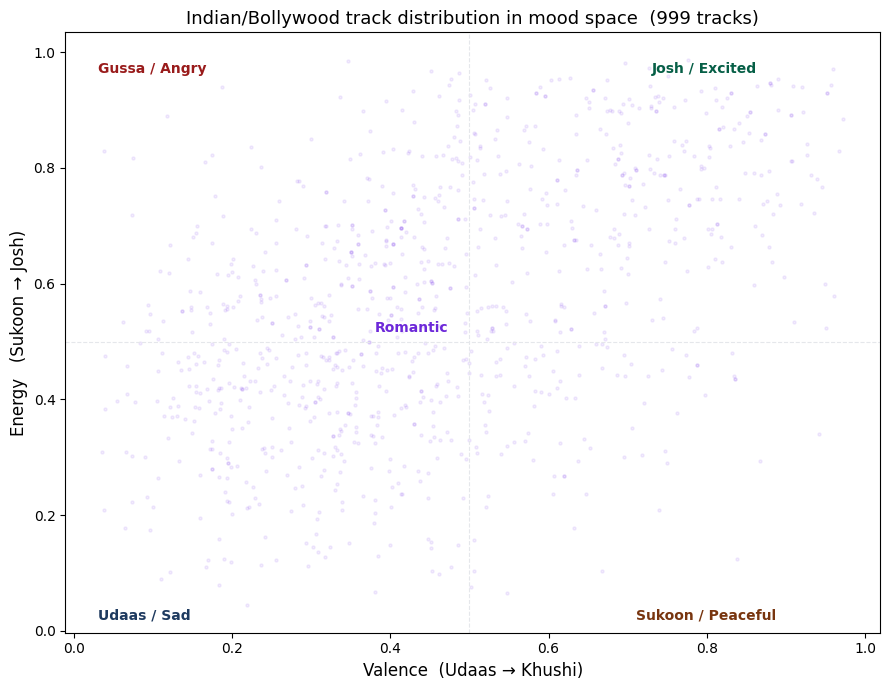

Saved to data/mood_space.png — add this image to your README


In [3]:

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(df.valence, df.energy, alpha=0.09, s=5, color='#7C3AED')

# Four emotional quadrants with Hindi labels
quadrants = [
    (0.04, 0.95, 'Gussa / Angry',    '#991B1B'),
    (0.72, 0.95, 'Josh / Excited',    '#065F46'),
    (0.04, 0.04, 'Udaas / Sad',       '#1E3A5F'),
    (0.70, 0.04, 'Sukoon / Peaceful', '#78350F'),
    (0.38, 0.52, 'Romantic',          '#6D28D9'),
]
for x, y, label, color in quadrants:
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, color=color, va='top', fontweight='bold')

ax.axvline(0.5, color='#E5E7EB', linewidth=0.8, linestyle='--')
ax.axhline(0.5, color='#E5E7EB', linewidth=0.8, linestyle='--')
ax.set_xlabel('Valence  (Udaas → Khushi)', fontsize=12)
ax.set_ylabel('Energy   (Sukoon → Josh)',   fontsize=12)
ax.set_title(f'Indian/Bollywood track distribution in mood space  ({len(df):,} tracks)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/mood_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/mood_space.png — add this image to your README')

correlation heatmap of audio features

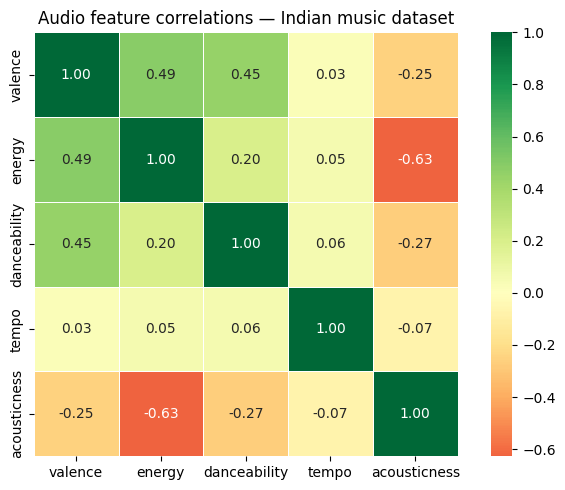

Valence-Energy correlation: 0.490
Good — valence and energy are independent enough for a 2D mood space


In [4]:
features = [f for f in ['valence', 'energy', 'danceability', 'tempo', 'acousticness']
            if f in df.columns]

corr = df[features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Audio feature correlations — Indian music dataset')
plt.tight_layout()
plt.show()

val_nrg_corr = corr.loc['valence', 'energy']
print(f'Valence-Energy correlation: {val_nrg_corr:.3f}')
if val_nrg_corr < 0.5:
    print('Good — valence and energy are independent enough for a 2D mood space')
else:
    print('Warning — high correlation. Consider using more diverse playlists.')

Sample a journey manually — quick mental test

In [5]:
from sklearn.metrics.pairwise import euclidean_distances

coords = df[['valence', 'energy']].values

def find_tracks_near(valence, energy, n=5):
    target = np.array([[valence, energy]])
    dists  = euclidean_distances(coords, target).flatten()
    idx    = dists.argsort()[:n]
    return df.iloc[idx][['name', 'artist', 'valence', 'energy']]

print('Tracks closest to UDAAS (sad + calm) — val=0.15, nrg=0.20:')
print(find_tracks_near(0.15, 0.20).to_string())
print()

print('Tracks closest to JOSH (excited + energetic) — val=0.80, nrg=0.85:')
print(find_tracks_near(0.80, 0.85).to_string())
print()

print('Tracks closest to ROMANTIC — val=0.75, nrg=0.45:')
print(find_tracks_near(0.75, 0.45).to_string())
print()

print('Tracks closest to SUKOON (peaceful) — val=0.65, nrg=0.20:')
print(find_tracks_near(0.65, 0.20).to_string())

Tracks closest to UDAAS (sad + calm) — val=0.15, nrg=0.20:
                                                 name                 artist  valence  energy
474                                              Shor           Arijit Anand   0.1600   0.195
36                                    Waqt Ki Baatein             Dream Note   0.2000   0.202
559                                            Aararo  Raghu Dixit;Anne Amie   0.1940   0.224
69                                    Pal Behta Jaaye           Vismay Patel   0.1960   0.223
735  Tujhe Jeena Hai Mere Bina Lofi - Slowed & Reverb    H Dixit;Lofi Person   0.0999   0.214

Tracks closest to JOSH (excited + energetic) — val=0.80, nrg=0.85:
                                       name                                   artist  valence  energy
996                        Haanikaarak Bapu     Pritam;Sarwar Khan;Sartaz Khan Barna    0.803   0.837
506                               Jee Karda               Pritam;Labh Janjua;Suzie Q    0.804   0.835
163